## Exploratory Data Analysis voor klachten train set
### Notebook EDA klachten classificatie voor correcte expertise

### Inhoud

1. [Introductie](#exploratory-data-analysis-voor-klachten-train-set)
2. [Data Analyse](#data-analyse)
   - [Visualisaties](#visualisaties)
   - [Productsspecifieke Analyse](#analyse-per-product)
   - [Wordclouds](#wordcloud-per-product)
3. [Data Preperation](#data-preperation)

In [ ]:
# Imports Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report
from scipy.stats import uniform, randint
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [ ]:
# Natural language ToolKit downloads
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

In [ ]:
#read training dataset
df = pd.read_csv("klacht_train.csv")

### Data Analyse

In [ ]:
# Klein Overzicht van dataset
df.head().T

,0,1,2,3,4
ID,2290288,1638808,1374984,2325523,1375617
Datum_ontvangst,2025-01-15,2023-11-04,2023-05-14,2025-02-03,2023-05-14
Product,Kredietregistratie,Bankrekening,Incasso,Incasso,Incasso
Omschrijving,XXXX was reinserted on my credit report after ...,Huntington bank is doing it again. \r\nThey ar...,Company ordered a local minnesota repossession...,"This company called "" tecco Systems '' has bee...","On XXXX XXXX 2015, at approximately XXXX CST, ..."
Antwoord_bedrijf,Closed with explanation,Closed with explanation,Closed with explanation,Closed with explanation,Closed with explanation
Omschrijving_lengte,71,629,1410,1926,995
Antwoord_lengte,23,23,23,23,23


In [ ]:
# Informatie over dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9527 entries, 0 to 9526
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   9527 non-null   int64 
 1   Datum_ontvangst      9527 non-null   object
 2   Product              9527 non-null   object
 3   Omschrijving         9527 non-null   object
 4   Antwoord_bedrijf     9527 non-null   object
 5   Omschrijving_lengte  9527 non-null   int64 
 6   Antwoord_lengte      9527 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 521.1+ KB


In [ ]:
# Kleine numerieke weergave van dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,9527.0,1.905142e+06,340222.350721,1290157.0,1602900.5,1930144.0,2207545.0,2537437.0
Omschrijving_lengte,9527.0,1.026427e+03,915.343693,12.0,381.0,713.0,1374.5,10761.0
Antwoord_lengte,9527.0,2.378902e+01,3.946444,6.0,23.0,23.0,23.0,31.0


In [ ]:
# Kolom/Product namen
df['Product'].unique()

array(['Kredietregistratie', 'Bankrekening', 'Incasso', 'Hypotheek',
       'Consumentenkrediet', 'Creditcard'], dtype=object)

In [ ]:
# Bedrijfsantwoorden
df['Antwoord_bedrijf'].unique()

array(['Closed with explanation', 'Closed with monetary relief',
       'Closed with non-monetary relief', 'Closed', 'Untimely response'],
      dtype=object)

In [ ]:
# Datum reeks dataset
df['Datum_ontvangst'].agg(['min', 'max'])

min    2023-03-19
max    2025-04-30
Name: Datum_ontvangst, dtype: object

In [ ]:
# informatie over dataset
df.shape
print("De dataset bevat {} rijen en {} kolommen.".format(df.shape[0], df.shape[1]))

De dataset bevat 9527 rijen en 7 kolommen.


In [ ]:
# Numerieke tabel
stats_num = df.describe(include='int64').T.reset_index().T
stats_num

,0,1,2
index,ID,Omschrijving_lengte,Antwoord_lengte
count,9527.0,9527.0,9527.0
mean,1905142.096883,1026.426997,23.789021
std,340222.350721,915.343693,3.946444
min,1290157.0,12.0,6.0
25%,1602900.5,381.0,23.0
50%,1930144.0,713.0,23.0
75%,2207545.0,1374.5,23.0
max,2537437.0,10761.0,31.0


In [ ]:
# Categorisch data overzicht
stats_cat = df.describe(include='object').T.reset_index()
stats_cat

,index,count,unique,top,freq
0,Datum_ontvangst,9527,770,2024-10-17,32
1,Product,9527,6,Incasso,2621
2,Omschrijving,9527,9497,I am filing this complaint because Experian ha...,5
3,Antwoord_bedrijf,9527,5,Closed with explanation,7414


In [46]:
# Verdeling verschillende expertises binnen de dataset
df['Product'].value_counts()

Product
Incasso               2621
Hypotheek             2108
Kredietregistratie    2072
Creditcard            1178
Bankrekening           946
Consumentenkrediet     602
Name: count, dtype: int64

In [ ]:
# Inlezen train en test data
train = pd.read_csv("klacht_train.csv")
test = pd.read_csv("klacht_test.csv")

In [ ]:
# Weergave lege waarden
train.isnull().sum()

ID                     0
Datum_ontvangst        0
Product                0
Omschrijving           0
Antwoord_bedrijf       0
Omschrijving_lengte    0
Antwoord_lengte        0
dtype: int64

In [ ]:
# Weergave duplicaten
train.duplicated().sum()

np.int64(0)

In [ ]:
# Korte Tabele lengte van klachten en antwoorden
train.drop(columns=['ID']).describe().T

,count,mean,std,min,25%,50%,75%,max
Omschrijving_lengte,9527.0,1026.426997,915.343693,12.0,381.0,713.0,1374.5,10761.0
Antwoord_lengte,9527.0,23.789021,3.946444,6.0,23.0,23.0,23.0,31.0


#### Visualisaties

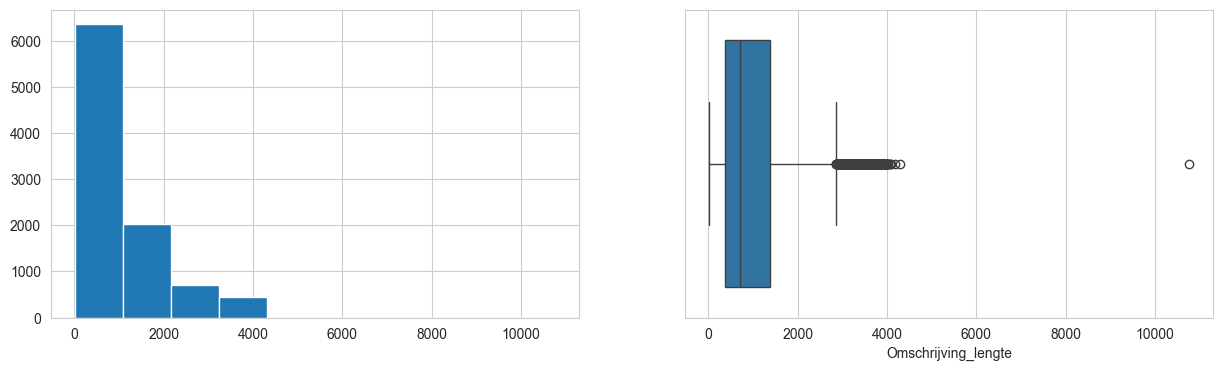

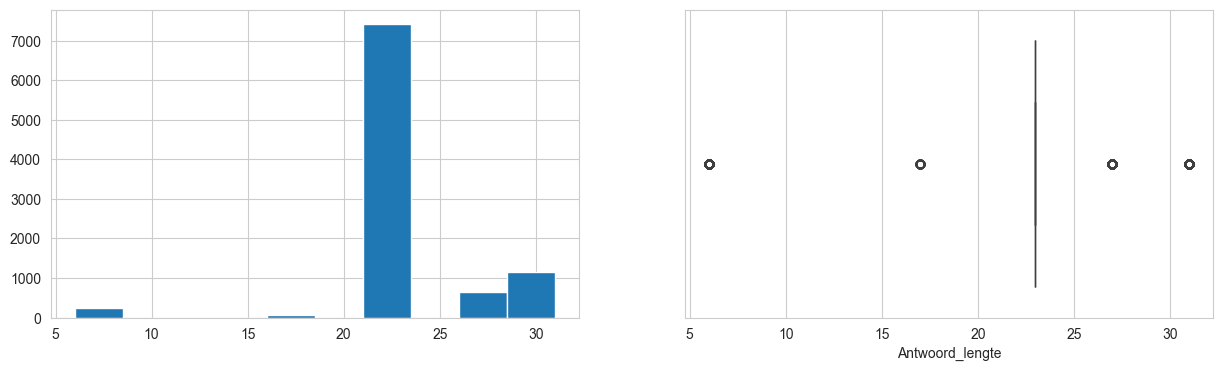

In [51]:
# bepaal numerieke variabelen
num_vars = train.drop(columns=['ID']).select_dtypes(include=np.number).columns.tolist()

# plot de verdeling van elke numerieke variabele in histogram en boxplot
for var in num_vars:
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    plt.hist(train[var])
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train[var])
    plt.show()


In [ ]:
# Numerieke weergave kort
train.select_dtypes(include="number").corr()

,ID,Omschrijving_lengte,Antwoord_lengte
ID,1.000000,0.005604,-0.001498
Omschrijving_lengte,0.005604,1.000000,-0.020285
Antwoord_lengte,-0.001498,-0.020285,1.000000


<Axes: >

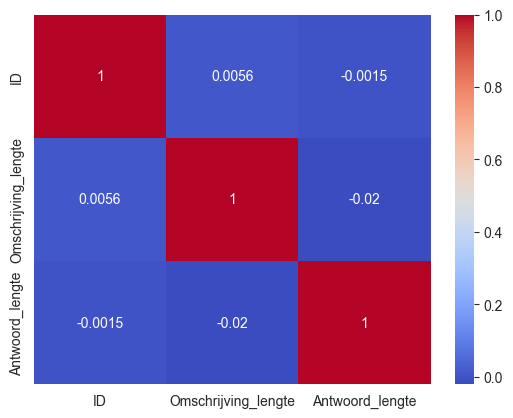

In [ ]:
# Heatmap Trainingsdata
sns.heatmap(train.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")

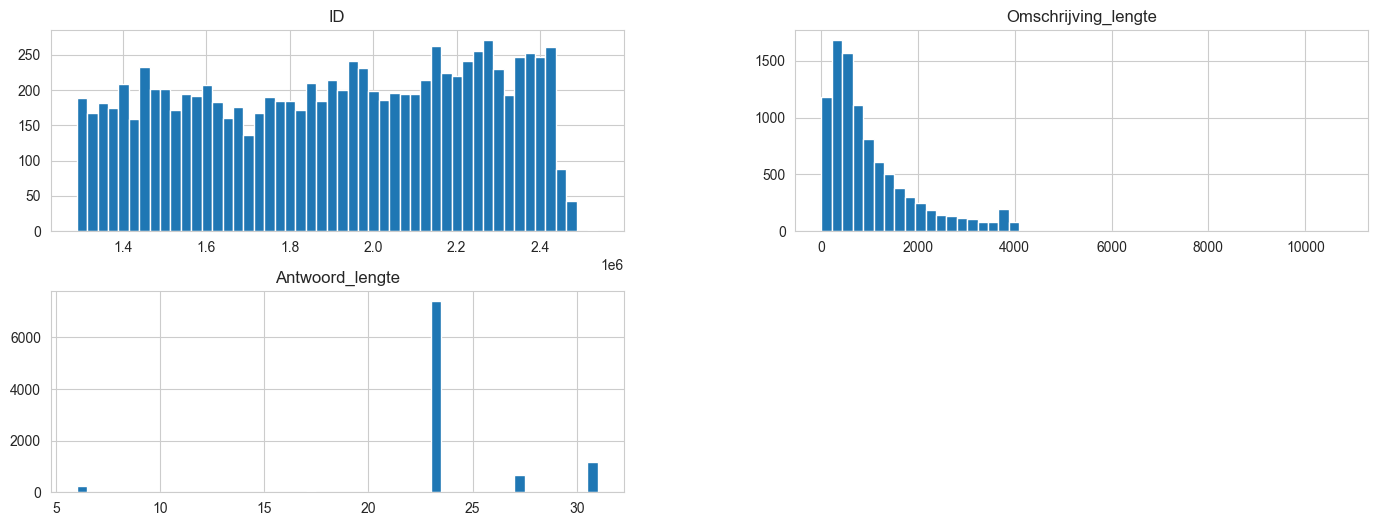

In [ ]:
# Histogrammen trainingsdata
train.hist(bins=50, figsize=(17, 6))
plt.show()

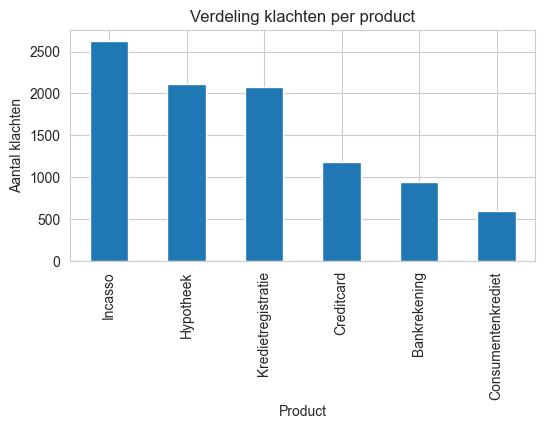

In [55]:
# Bar chart voor Product
plt.figure(figsize=(6,3))
train['Product'].value_counts().plot(kind="bar")
plt.title("Verdeling klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.show()

Incasso ontvangt de meeste klachten

### Analyse per product

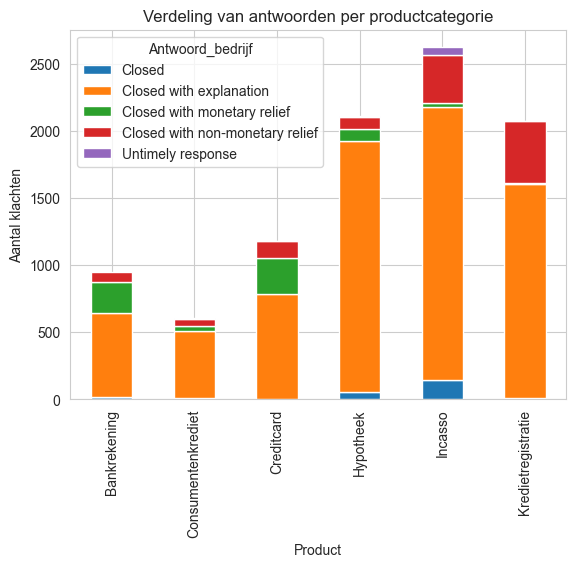

In [ ]:
# Staafdiagrammen trainingsdata
pd.crosstab(train["Product"], train["Antwoord_bedrijf"]).plot(kind="bar", stacked=True)
plt.title("Verdeling van antwoorden per productcategorie")
plt.ylabel("Aantal klachten")
plt.show()

#### Wordcloud per product

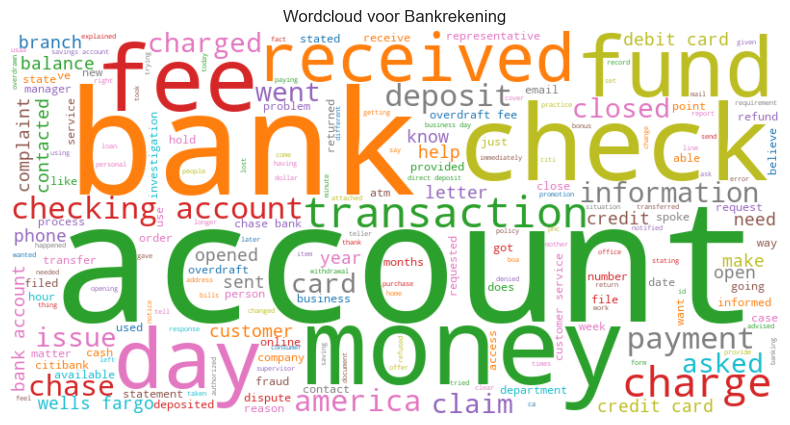

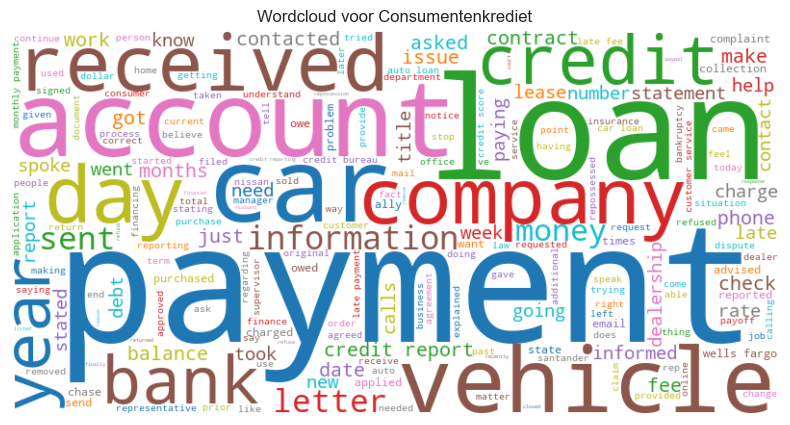

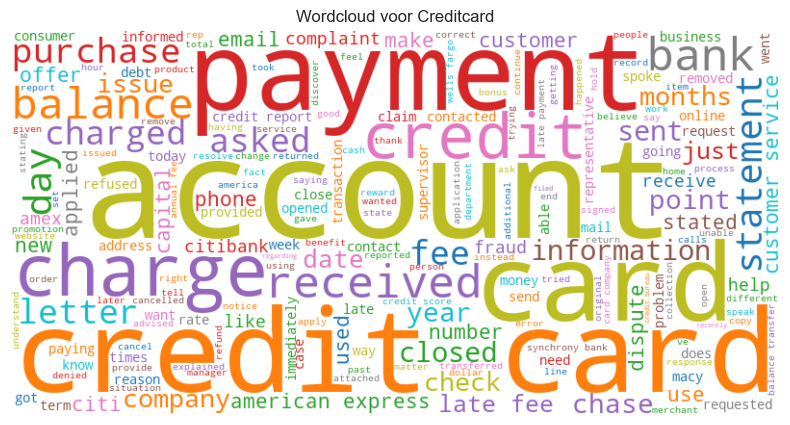

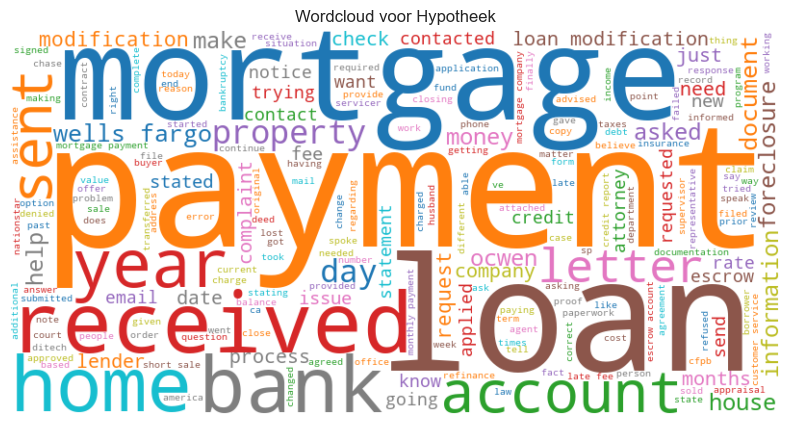

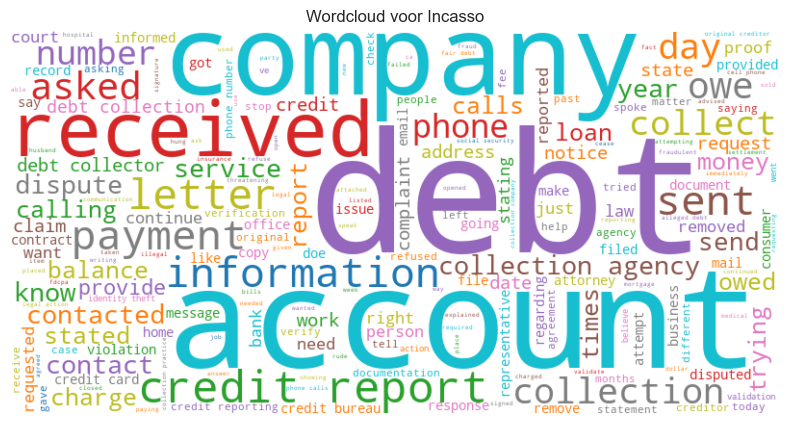

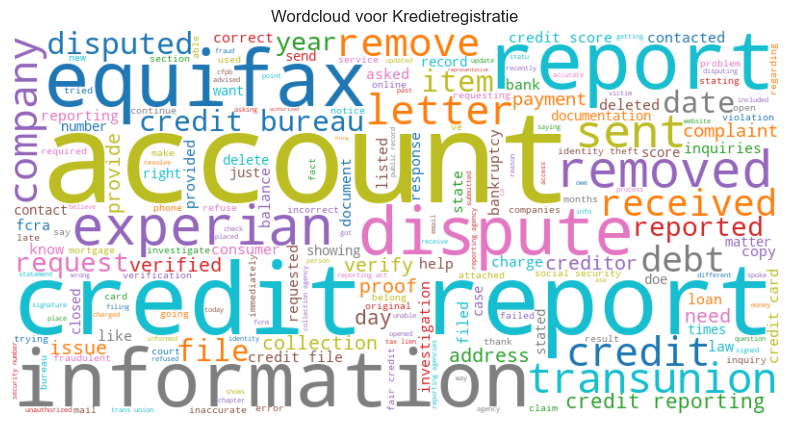

In [ ]:
# Wordclouds per product

#stopwoorden = set(stopwords.words("english"))
stopwoorden = list(set(ENGLISH_STOP_WORDS).union({
    'xxxx', 'xx', 'xxx', 'did', 'please', 'told', 'paid', 'called', 'time', 'said', 'month', 'pay',
    'a','b','c','d','e','f','g','h','i','j','k','l','m','n', 'o','p','q','r','s','t','u','v','w','x','y','z'
}))

train["clean"] = train["Omschrijving"].fillna("").str.lower().str.replace(r'[^a-z\s]', ' ', regex=True)

# Vectorizer
vectorizer = TfidfVectorizer(stop_words=stopwoorden, max_features=100000)
tfidf = vectorizer.fit_transform(train["clean"])
woorden = vectorizer.get_feature_names_out()

train["Top_keywords"] = [
    [woorden[i] for i in tfidf[row].toarray()[0].argsort()[-5:][::-1]]
    for row in range(tfidf.shape[0])
]

for product, groep in train.groupby("Product"):
    tekst = " ".join(groep["clean"])
    wc = WordCloud(width=800, height=400, background_color="white",
                   stopwords=set(stopwoorden), colormap="tab10").generate(tekst)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud voor {product}")
    plt.show()

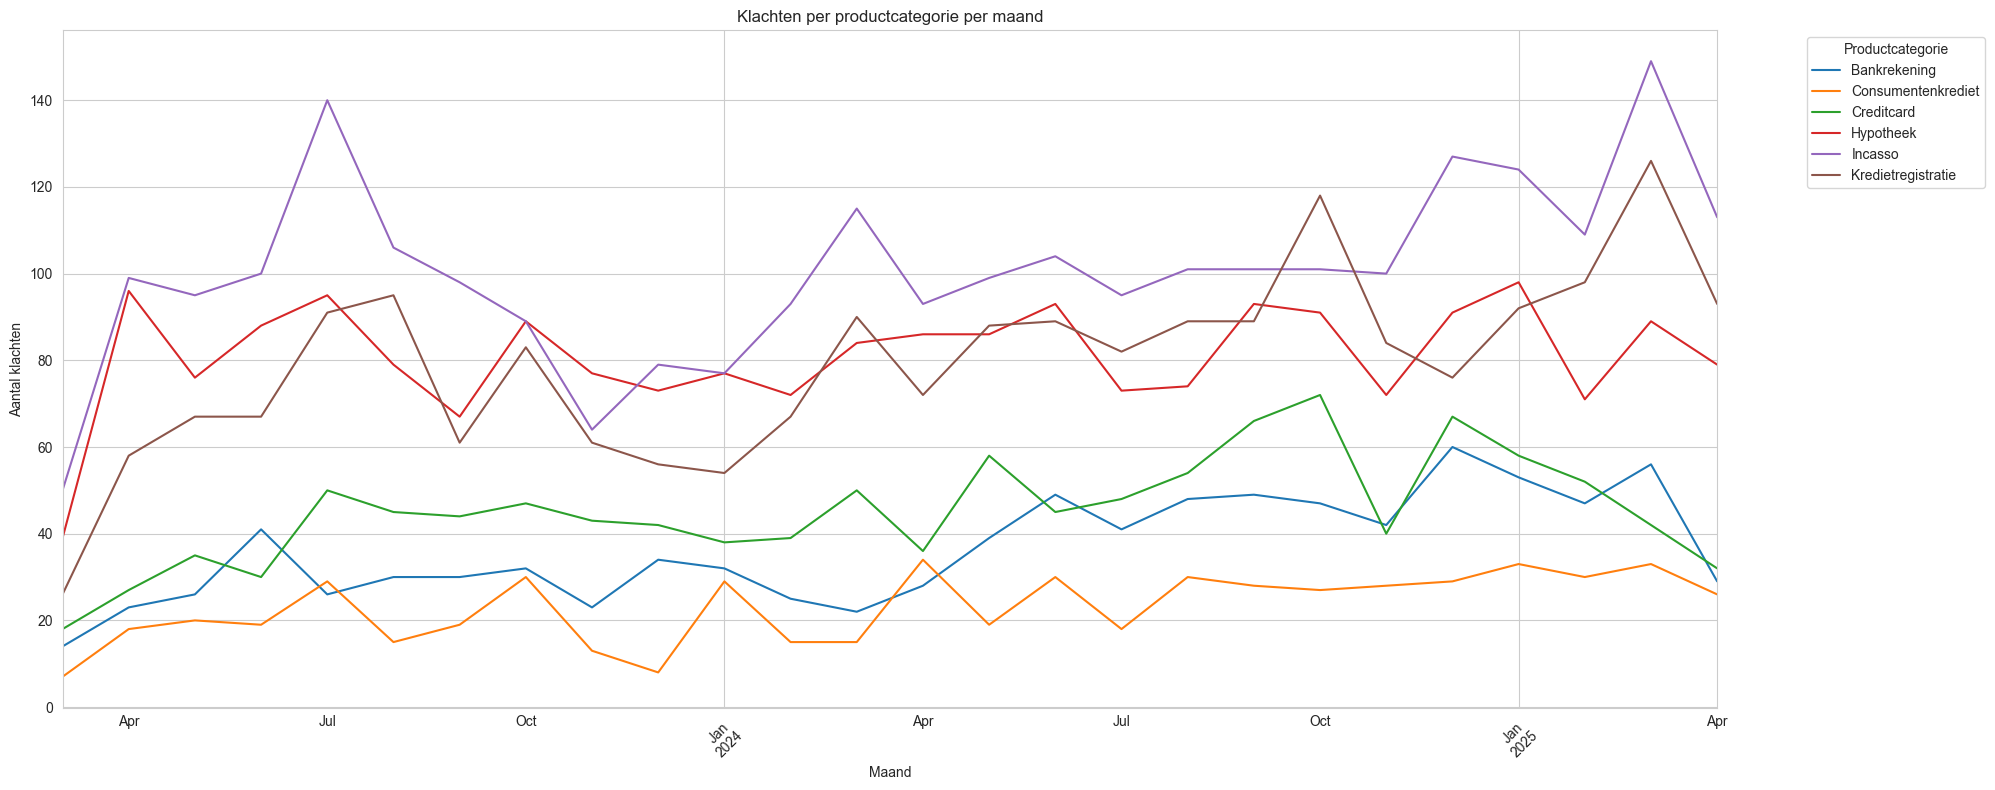

In [58]:
train["Datum_ontvangst"] = pd.to_datetime(train["Datum_ontvangst"])

#klachten per maand
klachten_per_maand = train.groupby([train["Datum_ontvangst"].dt.to_period("M"), "Product"]).size().unstack(fill_value=0)

#Plotten
sns.set_style("whitegrid")
klachten_per_maand.plot(figsize=(20,8))
plt.title("Klachten per productcategorie per maand")
plt.xlabel("Maand")
plt.ylabel("Aantal klachten")
plt.xticks(rotation=45)
plt.legend(title="Productcategorie", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Data Preperation

In [ ]:
# Stopwords en Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
# preprocessing, tokenizer
def preprocess_text(text):
    if pd.isna(text):
        return""
    
    text = text.lower() # maak lowercase
    text = re.sub(r'[^a-z\s]', ' ', text) # verwijdert speciale tekens 
    tokens = word_tokenize(text)

    tokens = [t for t in tokens if t not in stop_words] # verwijdert stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens] # lemmatizen

    return ' '.join(tokens)

df['Omschrijving_Cleaned'] = df['Omschrijving'].apply(preprocess_text)

In [ ]:
# Vergelijking omschrijving en opgeschoonde omschrijving
df[['Omschrijving', 'Omschrijving_Cleaned']].head()

,Omschrijving,Omschrijving_Cleaned
0,XXXX was reinserted on my credit report after ...,xxxx reinserted credit report previously deleted
1,Huntington bank is doing it again. \r\nThey ar...,huntington bank using deceptive tactic gaming ...
2,Company ordered a local minnesota repossession...,company ordered local minnesota repossession a...
3,"This company called "" tecco Systems '' has bee...",company called tecco system harassing month de...
4,"On XXXX XXXX 2015, at approximately XXXX CST, ...",xxxx xxxx approximately xxxx cst wife received...


#### Vordering in modelling.ipynb